# Experiment 1: DenseNet-201 Multi-Task Baseline — BreakHis 200X

**Objective:** Fine-tune a pretrained DenseNet-201 on BreakHis (200X magnification) to produce:
1. A **primary classification** baseline (benign vs malignant)
2. A **histopathological subtype classification** baseline (8 classes)
3. A saved, reusable **feature extractor** (1920-dim embeddings) for Experiment 3 (CNN+ViT fusion)

**Architecture:** Single shared DenseNet-201 backbone → two classification heads (multi-task)

> This notebook is **Experiment 1 of 3**. Do not add fusion, attention, or alternate architectures.

---
### Deliverables
| Artifact | Path |
|---|---|
| Patient-level split | `/content/drive/MyDrive/output_CNN/split.csv` |
| Best checkpoint | `/content/drive/MyDrive/output_CNN/best_densenet201.pth` |
| Test-set metrics | `/content/drive/MyDrive/output_CNN/test_metrics.json` |
| Confusion matrices | `/content/drive/MyDrive/output_CNN/confusion_matrices.png` |
| Training history | `/content/drive/MyDrive/output_CNN/training_history.csv` |
| Sample embeddings | `/content/drive/MyDrive/output_CNN/sample_embeddings.pt` |

In [ ]:
# ============================================================
# Environment Setup
# ============================================================
!pip install -q kagglehub kaggle scikit-learn seaborn tqdm

##  Kaggle API Authentication

Kaggle authentication is configured using `KAGGLE_API_TOKEN` environment variable.
`kagglehub` will automatically authenticate using this token.

In [ ]:
# ============================================================
# KAGGLE API AUTHENTICATION
# ============================================================
import os, json

# Set Kaggle API Token
os.environ["KAGGLE_API_TOKEN"] = "KGAT_902d4b57555170250ba954efdc16ea05"

# Also ensure ~/.kaggle directory exists for compatibility
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

print("Kaggle authentication configured (KAGGLE_API_TOKEN active).")

Kaggle authentication configured (KAGGLE_API_TOKEN active).


In [ ]:
# ============================================================
# Mount Google Drive & Create Output Directory
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/output_CNN"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Output directory ready: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory ready: /content/drive/MyDrive/output_CNN


In [ ]:
# ============================================================
# Experiment Configuration
# ============================================================
# All hyperparameters and paths in one place.
# This CONFIG is the single source of truth for this experiment.

CONFIG = {
    # --- Data ---
    "data": {
        "dataset_id": "trexbytes/breakhislink",
        "data_dir": "/content/drive/MyDrive/BreakHis",
        "magnification": "200X",
        "input_size": 224,
        "batch_size": 16,
        "num_workers": 0,
        "pin_memory": True,
    },
    # --- Model ---
    "model": {
        "backbone": "densenet201",
        "pretrained": True,
        "primary_num_classes": 2,
        "subtype_num_classes": 8,
        "embedding_dim": 1920,
        "dropout": 0.4,
        "unfreeze_last_n_blocks": 1,
    },
    # --- Cross-Validation ---
    "cv": {
        "n_folds": 5,
        "epochs_per_fold": 6,
    },
    # --- Final Training ---
    "final": {
        "phase1_epochs": 4,
        "phase2_epochs": 15,
        "early_stopping_patience": 7,
    },
    # --- Optimizer ---
    "optim": {
        "name": "adamw",
        "lr_head": 1e-3,
        "lr_backbone": 1e-5,
        "weight_decay": 1e-4,
        "scheduler": "cosine",
        "mixed_precision": True,
    },
    # --- Multi-Task Loss ---
    "loss": {
        "primary": {
            "name": "cross_entropy",
            "label_smoothing": 0.05,
        },
        "subtype": {
            "name": "cross_entropy",
            "label_smoothing": 0.05,
        },
        "subtype_weight": 1.0,
        "use_class_weights": True,
        "use_focal": False,
        "focal_gamma": 2.0,
    },
    # --- Normalization ---
    "normalization": "imagenet",
    # --- Augmentation ---
    "augmentation": {
        "horizontal_flip": True,
        "vertical_flip": True,
        "rotation_degrees": 20,
        "color_jitter": True,
        "heavy_augmentation": False,
    },
    # --- Reproducibility ---
    "seed": 42,
    # --- Checkpointing ---
    "checkpoint": {
        "monitor": "val_subtype_macro_f1",
        "mode": "max",
        "save_best": True,
        "save_periodic": True,
    },
    # --- Smoke Test ---
    "smoke_test": False,
}

# Derived paths
SAVE_DIR = "/content/drive/MyDrive/output_CNN"
SPLIT_CSV_PATH = os.path.join(SAVE_DIR, "split.csv")
BEST_CHECKPOINT_PATH = os.path.join(SAVE_DIR, "best_densenet201.pth")

print("\u2705 Configuration loaded.")
print(f"   Backbone:      {CONFIG['model']['backbone']}")
print(f"   Dataset ID:    {CONFIG['data']['dataset_id']}")
print(f"   Magnification: {CONFIG['data']['magnification']}")
print(f"   Batch size:    {CONFIG['data']['batch_size']}")
print(f"   Embedding dim: {CONFIG['model']['embedding_dim']}")
print(f"   Smoke test:    {CONFIG['smoke_test']}")

✅ Configuration loaded.
   Backbone:      densenet201
   Dataset ID:    trexbytes/breakhislink
   Magnification: 200X
   Batch size:    16
   Embedding dim: 1920
   Smoke test:    False


In [ ]:
# ============================================================
# Imports & Reproducibility
# ============================================================
import os, sys, json, random, re, glob, time, warnings, copy, shutil, zipfile
from collections import Counter, OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore', category=UserWarning)

# --- Reproducibility ---
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to {seed}")

seed_everything(CONFIG['seed'])

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Random seed set to 42
Device: cuda
   GPU: Tesla T4
   GPU Memory: 15.6 GB


In [ ]:
import kagglehub
import zipfile, shutil

data_dir_config = CONFIG['data']['data_dir'] # Keep original data_dir for reference if needed
dataset_id = CONFIG['data']['dataset_id']

print(f" Downloading dataset via kagglehub: {dataset_id}")
# Download latest version using kagglehub
path = kagglehub.dataset_download(dataset_id)
print("Path to dataset files:", path)

# Create a temporary directory for extraction if needed, or extract directly to 'path'
extraction_dir = os.path.join(path, 'extracted_data')
os.makedirs(extraction_dir, exist_ok=True)

# Check for any zip files in the downloaded path and extract them
zip_files = glob.glob(os.path.join(path, '**', '*.zip'), recursive=True)
if zip_files:
    for zf in zip_files:
        print(f"   Extracting {zf} to {extraction_dir}...")
        with zipfile.ZipFile(zf, 'r') as z:
            z.extractall(extraction_dir)
    # After extraction, update the data_dir in CONFIG to point to the extracted location
    CONFIG['data']['data_dir'] = extraction_dir
else:
    # If no zips, the data is likely directly in the downloaded 'path'
    CONFIG['data']['data_dir'] = path

existing_pngs = glob.glob(os.path.join(CONFIG['data']['data_dir'], '**', '*.png'), recursive=True)

assert len(existing_pngs) > 0, f"Download failed \u2014 no PNG images found in {CONFIG['data']['data_dir']}"
print(f"Dataset ready: {len(existing_pngs)} images found in {CONFIG['data']['data_dir']}")

Path to dataset files: /root/.cache/kagglehub/datasets/trexbytes/breakhislink/versions/1
Dataset ready: 7909 images found in /root/.cache/kagglehub/datasets/trexbytes/breakhislink/versions/1


## Mandatory Pre-Training Data Audit

> **Section 3 of the plan:** Do not skip or reorder.

1. Verify directory structure
2. Extract patient/case IDs from filenames
3. Report class distributions (Task A and Task B)
4. Create patient-level stratified split (70/15/15)
5. Save `split.csv` as shared artifact for all experiments

In [ ]:
# ============================================================
# Directory Structure Verification & Data Audit
# ============================================================
data_dir = CONFIG['data']['data_dir']
target_mag = CONFIG['data']['magnification']  # "200X"

print("=" * 60)
print("DIRECTORY STRUCTURE VERIFICATION")
print("=" * 60)

# 1. Find all PNG images recursively
all_images = glob.glob(os.path.join(data_dir, '**', '*.png'), recursive=True)
print(f"\nTotal PNG images found: {len(all_images)}")
assert len(all_images) > 0, f" No PNG images found in {data_dir}!"

# 2. Detect magnification from directory structure
mag_counts = {}
for img in all_images:
    path_parts = img.replace('\\', '/').split('/')
    for part in path_parts:
        if re.match(r'^\d+X$', part):
            mag_counts[part] = mag_counts.get(part, 0) + 1

if mag_counts:
    print(f"\nMagnification distribution (from directory structure):")
    for mag, count in sorted(mag_counts.items()):
        marker = " TARGET" if mag == target_mag else ""
        print(f"  {mag}: {count} images{marker}")
else:
    print("\nMagnification not found in directory paths will parse from filenames.")

# 3. Filter for target magnification
mag_images = []
for img in all_images:
    path_normalized = img.replace('\\', '/')
    if f'/{target_mag}/' in path_normalized:
        mag_images.append(img)

# Fallback: parse magnification from filename
if len(mag_images) == 0:
    mag_num = target_mag.replace('X', '')
    for img in all_images:
        fname = os.path.basename(img).replace('.png', '')
        parts = fname.split('-')
        if len(parts) >= 4 and parts[-2] == mag_num:
            mag_images.append(img)

print(f"\n{target_mag} images found: {len(mag_images)}")
assert len(mag_images) > 0, f"No {target_mag} images found! Check dataset structure."

# 4. Subtype and label mapping
SUBTYPE_FOLDERS = {
    'adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma',
    'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma'
}

SUBTYPE_CODE_MAP = {
    'A': 'adenosis', 'F': 'fibroadenoma', 'PT': 'phyllodes_tumor', 'TA': 'tubular_adenoma',
    'DC': 'ductal_carcinoma', 'LC': 'lobular_carcinoma', 'MC': 'mucinous_carcinoma',
    'PC': 'papillary_carcinoma',
}

PRIMARY_FROM_SUBTYPE = {
    'adenosis': 'benign', 'fibroadenoma': 'benign',
    'phyllodes_tumor': 'benign', 'tubular_adenoma': 'benign',
    'ductal_carcinoma': 'malignant', 'lobular_carcinoma': 'malignant',
    'mucinous_carcinoma': 'malignant', 'papillary_carcinoma': 'malignant',
}

# 5. Parse each image
records = []
parse_errors = []

for img_path in mag_images:
    path_normalized = img_path.replace('\\', '/')
    fname = os.path.basename(img_path)
    fname_no_ext = fname.replace('.png', '')

    # --- Determine subtype from directory path ---
    subtype = None
    path_lower = path_normalized.lower()
    for st in SUBTYPE_FOLDERS:
        if f'/{st}/' in path_lower:
            subtype = st
            break

    # Fallback: from filename prefix  SOB_B_A-..., SOB_M_DC-...
    if subtype is None:
        prefix = fname_no_ext.split('-')[0]   # e.g. SOB_B_A
        parts = prefix.split('_')
        if len(parts) >= 3:
            code_str = '_'.join(parts[2:])
            subtype = SUBTYPE_CODE_MAP.get(code_str)

    if subtype is None:
        parse_errors.append(f"Could not determine subtype: {img_path}")
        continue

    primary = PRIMARY_FROM_SUBTYPE[subtype]

    # --- Extract patient/case ID from filename ---
    parts = fname_no_ext.split('-')
    if len(parts) >= 4:
        case_id = '-'.join(parts[1:-2])
        subtype_prefix = parts[0].split('_')[-1]
        patient_id = f"{subtype_prefix}_{case_id}"
    else:
        patient_id = fname_no_ext
        parse_errors.append(f"Unexpected filename format: {fname}")

    records.append({
        'filepath': img_path,
        'filename': fname,
        'patient_id': patient_id,
        'magnification': target_mag,
        'primary_label': primary,
        'subtype_label': subtype,
    })

if parse_errors:
    print(f"\nParse warnings ({len(parse_errors)}):")
    for err in parse_errors[:5]:
        print(f"  {err}")
    if len(parse_errors) > 5:
        print(f"  ... and {len(parse_errors) - 5} more")

audit_df = pd.DataFrame(records)
assert len(audit_df) > 0, "No valid records after parsing!"

# 6. Verify all 8 subtypes are present
found_subtypes = set(audit_df['subtype_label'].unique())
missing = SUBTYPE_FOLDERS - found_subtypes
if missing:
    print(f"\n Missing subtypes: {missing}")
    print("   Proceeding with available subtypes.")
else:
    print(f"\nAll 8 expected subtypes found.")

# 7. Print class distributions
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION REPORT")
print("=" * 60)

print("\n--- Task A: Primary Classification (Benign vs Malignant) ---")
primary_counts = audit_df['primary_label'].value_counts()
for label, count in primary_counts.items():
    pct = 100 * count / len(audit_df)
    print(f"  {label:12s}: {count:5d} images ({pct:.1f}%)")

print(f"\n--- Task B: Subtype Classification (8 classes) ---")
subtype_counts = audit_df['subtype_label'].value_counts()
for label, count in subtype_counts.items():
    pct = 100 * count / len(audit_df)
    print(f"  {label:25s}: {count:5d} images ({pct:.1f}%)")

print(f"\n--- Patient/Case Counts ---")
n_patients = audit_df['patient_id'].nunique()
print(f"  Total patients/cases: {n_patients}")

patient_subtype = audit_df.groupby('patient_id')['subtype_label'].first().value_counts()
print(f"\n  Patients per subtype:")
for label, count in patient_subtype.items():
    print(f"    {label:25s}: {count:3d} patients")

print(f"\nData audit complete: {len(audit_df)} images from {n_patients} patients.")

DIRECTORY STRUCTURE VERIFICATION

Total PNG images found: 7909

Magnification distribution (from directory structure):
  100X: 2081 images
  200X: 2013 images TARGET
  400X: 1820 images
  40X: 1995 images

200X images found: 2013

All 8 expected subtypes found.

CLASS DISTRIBUTION REPORT

--- Task A: Primary Classification (Benign vs Malignant) ---
  malignant   :  1390 images (69.1%)
  benign      :   623 images (30.9%)

--- Task B: Subtype Classification (8 classes) ---
  ductal_carcinoma         :   896 images (44.5%)
  fibroadenoma             :   264 images (13.1%)
  mucinous_carcinoma       :   196 images (9.7%)
  lobular_carcinoma        :   163 images (8.1%)
  tubular_adenoma          :   140 images (7.0%)
  papillary_carcinoma      :   135 images (6.7%)
  adenosis                 :   111 images (5.5%)
  phyllodes_tumor          :   108 images (5.4%)

--- Patient/Case Counts ---
  Total patients/cases: 82

  Patients per subtype:
    ductal_carcinoma         :  38 patients
    

In [ ]:
# ============================================================
# Patient-Level Stratified Split (70/15/15)
# ============================================================
print("=" * 60)
print("PATIENT-LEVEL STRATIFIED SPLIT")
print("=" * 60)

# Get unique patients with their subtype
patient_info = audit_df.groupby('patient_id').agg({
    'subtype_label': 'first',
    'primary_label': 'first',
    'filepath': 'count'
}).rename(columns={'filepath': 'num_images'}).reset_index()

print(f"\nTotal patients: {len(patient_info)}")

# Check if existing split.csv can be reused
_reuse = False
if os.path.exists(SPLIT_CSV_PATH):
    print(f"\n\U0001f4c4 Found existing split at: {SPLIT_CSV_PATH}")
    existing_split = pd.read_csv(SPLIT_CSV_PATH)
    existing_patients = set(existing_split['patient_id'].unique())
    current_patients = set(patient_info['patient_id'].unique())
    if current_patients.issubset(existing_patients):
        print("   Existing split covers all current patients \u2014 reusing it.")
        split_df = existing_split[
            existing_split['magnification'] == CONFIG['data']['magnification']
        ].copy()
        _reuse = True
    else:
        print("   \u26a0\ufe0f Existing split doesn't cover all patients \u2014 creating new split.")

if not _reuse:
    patients = patient_info['patient_id'].values
    subtypes = patient_info['subtype_label'].values

    # First split: 85% trainval, 15% test
    try:
        patients_trainval, patients_test = train_test_split(
            patients, test_size=0.15, random_state=CONFIG['seed'],
            stratify=subtypes
        )
    except ValueError:
        print("   \u26a0\ufe0f Stratified split failed for test \u2014 using non-stratified.")
        patients_trainval, patients_test = train_test_split(
            patients, test_size=0.15, random_state=CONFIG['seed']
        )

    # Second split: trainval -> ~82.35% train, ~17.65% val
    trainval_mask = patient_info['patient_id'].isin(patients_trainval)
    trainval_subtypes = patient_info[trainval_mask]['subtype_label'].values
    trainval_patients = patient_info[trainval_mask]['patient_id'].values

    try:
        patients_train, patients_val = train_test_split(
            trainval_patients, test_size=15/85,
            random_state=CONFIG['seed'], stratify=trainval_subtypes
        )
    except ValueError:
        print("   \u26a0\ufe0f Stratified split failed for val \u2014 using non-stratified.")
        patients_train, patients_val = train_test_split(
            trainval_patients, test_size=15/85, random_state=CONFIG['seed']
        )

    train_set = set(patients_train)
    val_set = set(patients_val)
    test_set = set(patients_test)

    audit_df['split'] = audit_df['patient_id'].apply(
        lambda pid: 'train' if pid in train_set
        else ('val' if pid in val_set else 'test')
    )

    split_df = audit_df[['filepath', 'patient_id', 'magnification',
                         'primary_label', 'subtype_label', 'split']].copy()
    split_df.to_csv(SPLIT_CSV_PATH, index=False)
    print(f"\n\u2705 Split saved to: {SPLIT_CSV_PATH}")

# --- Verification: no patient overlap ---
train_p = set(split_df[split_df['split'] == 'train']['patient_id'])
val_p   = set(split_df[split_df['split'] == 'val']['patient_id'])
test_p  = set(split_df[split_df['split'] == 'test']['patient_id'])

assert len(train_p & val_p)  == 0, "\u274c Patient leak: train \u2229 val"
assert len(train_p & test_p) == 0, "\u274c Patient leak: train \u2229 test"
assert len(val_p & test_p)   == 0, "\u274c Patient leak: val \u2229 test"
print("\u2705 No patient overlap \u2014 split verified.")

# --- Print split summary ---
print("\n" + "=" * 60)
print("SPLIT SUMMARY")
print("=" * 60)

for split_name in ['train', 'val', 'test']:
    subset = split_df[split_df['split'] == split_name]
    n_imgs = len(subset)
    n_pats = subset['patient_id'].nunique()
    pct = 100 * n_imgs / len(split_df)
    print(f"\n{split_name.upper():5s}: {n_imgs:5d} images, {n_pats:3d} patients ({pct:.1f}%)")
    for st in sorted(subset['subtype_label'].unique()):
        st_count = len(subset[subset['subtype_label'] == st])
        st_pats  = subset[subset['subtype_label'] == st]['patient_id'].nunique()
        print(f"    {st:25s}: {st_count:4d} imgs, {st_pats:2d} patients")

# Apply smoke-test reduction
if CONFIG['smoke_test']:
    print("\n\u26a0\ufe0f SMOKE TEST MODE \u2014 reducing data size")
    split_df = split_df.groupby(['split', 'subtype_label']).head(10).reset_index(drop=True)
    print(f"   Reduced to {len(split_df)} images")

PATIENT-LEVEL STRATIFIED SPLIT

Total patients: 82

📄 Found existing split at: /content/drive/MyDrive/output_CNN/split.csv
   Existing split covers all current patients — reusing it.
✅ No patient overlap — split verified.

SPLIT SUMMARY

TRAIN:  1444 images,  56 patients (71.7%)
    adenosis                 :   47 imgs,  2 patients
    ductal_carcinoma         :  628 imgs, 26 patients
    fibroadenoma             :  208 imgs,  7 patients
    lobular_carcinoma        :  117 imgs,  3 patients
    mucinous_carcinoma       :  166 imgs,  7 patients
    papillary_carcinoma      :  101 imgs,  4 patients
    phyllodes_tumor          :   66 imgs,  2 patients
    tubular_adenoma          :  111 imgs,  5 patients

VAL  :   289 images,  13 patients (14.4%)
    adenosis                 :   32 imgs,  1 patients
    ductal_carcinoma         :  129 imgs,  6 patients
    fibroadenoma             :   21 imgs,  1 patients
    lobular_carcinoma        :   18 imgs,  1 patients
    mucinous_carcinoma       

## Data Pipeline

- PyTorch `Dataset` / `DataLoader`
- Input: 224\u00d7224, ImageNet normalization
- **Train augmentation:** horizontal/vertical flip, rotation (\u00b120\u00b0), mild color jitter
- **Val/Test:** resize + normalize only

In [ ]:
# ============================================================
# PyTorch Dataset & DataLoaders
# ============================================================

# --- Transforms ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
input_size = CONFIG['data']['input_size']

aug_cfg = CONFIG['augmentation']
train_tfm_list = [transforms.Resize((input_size, input_size))]
if aug_cfg['horizontal_flip']:
    train_tfm_list.append(transforms.RandomHorizontalFlip(p=0.5))
if aug_cfg['vertical_flip']:
    train_tfm_list.append(transforms.RandomVerticalFlip(p=0.5))
if aug_cfg['rotation_degrees'] > 0:
    train_tfm_list.append(transforms.RandomRotation(aug_cfg['rotation_degrees']))
if aug_cfg['color_jitter']:
    train_tfm_list.append(
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02)
    )
train_tfm_list += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
train_transform = transforms.Compose(train_tfm_list)

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# --- Label Mappings ---
PRIMARY_LABEL_MAP = {'benign': 0, 'malignant': 1}
PRIMARY_IDX_TO_LABEL = {v: k for k, v in PRIMARY_LABEL_MAP.items()}

SUBTYPE_LABEL_MAP = {
    'adenosis': 0, 'fibroadenoma': 1, 'phyllodes_tumor': 2, 'tubular_adenoma': 3,
    'ductal_carcinoma': 4, 'lobular_carcinoma': 5, 'mucinous_carcinoma': 6,
    'papillary_carcinoma': 7,
}
SUBTYPE_IDX_TO_LABEL = {v: k for k, v in SUBTYPE_LABEL_MAP.items()}

# --- Dataset Class ---
class BreakHisDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        primary = PRIMARY_LABEL_MAP[row['primary_label']]
        subtype = SUBTYPE_LABEL_MAP[row['subtype_label']]
        return image, primary, subtype

# --- Create DataLoaders ---
train_df = split_df[split_df['split'] == 'train'].copy()
val_df   = split_df[split_df['split'] == 'val'].copy()
test_df  = split_df[split_df['split'] == 'test'].copy()

train_dataset = BreakHisDataset(train_df, transform=train_transform)
val_dataset   = BreakHisDataset(val_df,   transform=val_transform)
test_dataset  = BreakHisDataset(test_df,  transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['data']['batch_size'], shuffle=True,
    num_workers=CONFIG['data']['num_workers'], pin_memory=CONFIG['data']['pin_memory'],
    drop_last=False,
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG['data']['batch_size'], shuffle=False,
    num_workers=CONFIG['data']['num_workers'], pin_memory=CONFIG['data']['pin_memory'],
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['data']['batch_size'], shuffle=False,
    num_workers=CONFIG['data']['num_workers'], pin_memory=CONFIG['data']['pin_memory'],
)

# --- Assertions ---
assert len(train_loader) > 0, "\u274c Train DataLoader is empty!"
assert len(val_loader)   > 0, "\u274c Val DataLoader is empty!"
assert len(test_loader)  > 0, "\u274c Test DataLoader is empty!"

sample_imgs, sample_pri, sample_sub = next(iter(train_loader))
assert sample_imgs.shape[1:] == (3, input_size, input_size), \
    f"Unexpected image shape: {sample_imgs.shape}"
assert sample_pri.max().item() < CONFIG['model']['primary_num_classes'], \
    "Invalid primary class index!"
assert sample_sub.max().item() < CONFIG['model']['subtype_num_classes'], \
    "Invalid subtype class index!"

print(f"\n\u2705 DataLoaders created:")
print(f"   Train: {len(train_dataset):5d} images, {len(train_loader):3d} batches")
print(f"   Val:   {len(val_dataset):5d} images, {len(val_loader):3d} batches")
print(f"   Test:  {len(test_dataset):5d} images, {len(test_loader):3d} batches")
print(f"   Batch shape: {sample_imgs.shape}")


✅ DataLoaders created:
   Train:  1444 images,  91 batches
   Val:     289 images,  19 batches
   Test:    280 images,  18 batches
   Batch shape: torch.Size([16, 3, 224, 224])


In [ ]:
# ============================================================
# Class Weights Computation
# ============================================================
train_primary_labels = train_df['primary_label'].map(PRIMARY_LABEL_MAP).values
train_subtype_labels = train_df['subtype_label'].map(SUBTYPE_LABEL_MAP).values

primary_classes = np.array(sorted(PRIMARY_LABEL_MAP.values()))
primary_weights = compute_class_weight('balanced', classes=primary_classes, y=train_primary_labels)
primary_weights_tensor = torch.FloatTensor(primary_weights).to(device)

subtype_classes = np.array(sorted(SUBTYPE_LABEL_MAP.values()))
subtype_weights = compute_class_weight('balanced', classes=subtype_classes, y=train_subtype_labels)
subtype_weights_tensor = torch.FloatTensor(subtype_weights).to(device)

print("\u2705 Class weights computed from training set:")
print(f"\n   Primary (benign/malignant):")
for idx, w in enumerate(primary_weights):
    label = PRIMARY_IDX_TO_LABEL[idx]
    count = int((train_primary_labels == idx).sum())
    print(f"     {label:12s}: weight={w:.4f}  (n={count})")

print(f"\n   Subtype (8 classes):")
for idx, w in enumerate(subtype_weights):
    label = SUBTYPE_IDX_TO_LABEL[idx]
    count = int((train_subtype_labels == idx).sum())
    print(f"     {label:25s}: weight={w:.4f}  (n={count})")

✅ Class weights computed from training set:

   Primary (benign/malignant):
     benign      : weight=1.6713  (n=432)
     malignant   : weight=0.7134  (n=1012)

   Subtype (8 classes):
     adenosis                 : weight=3.8404  (n=47)
     fibroadenoma             : weight=0.8678  (n=208)
     phyllodes_tumor          : weight=2.7348  (n=66)
     tubular_adenoma          : weight=1.6261  (n=111)
     ductal_carcinoma         : weight=0.2874  (n=628)
     lobular_carcinoma        : weight=1.5427  (n=117)
     mucinous_carcinoma       : weight=1.0873  (n=166)
     papillary_carcinoma      : weight=1.7871  (n=101)


## Model Architecture

```
DenseNet-201 (ImageNet-pretrained)
        |
   features + ReLU + AdaptiveAvgPool2d
        |
  1920-dim embedding  <-- saved for Experiment 3
        |
   +----+----+
   |         |
Head A     Head B
Dropout    Dropout
Linear     Linear
   |         |
2 classes  8 classes
(B/M)      (subtypes)
```

In [ ]:
# ============================================================
# DenseNet-201 Multi-Task Model
# ============================================================

class DenseNet201MultiTask(nn.Module):
    '''DenseNet-201 backbone with two classification heads for multi-task learning.

    Embedding layer: features -> ReLU -> AdaptiveAvgPool2d -> Flatten
    Embedding dim:   1920 (DenseNet-201 default)
    '''

    def __init__(self, config):
        super().__init__()
        emb_dim  = config['model']['embedding_dim']   # 1920
        dropout  = config['model']['dropout']
        n_primary = config['model']['primary_num_classes']
        n_subtype = config['model']['subtype_num_classes']

        # Load pretrained DenseNet-201
        if config['model']['pretrained']:
            weights = models.DenseNet201_Weights.IMAGENET1K_V1
            base = models.densenet201(weights=weights)
            print("   Loaded ImageNet-pretrained DenseNet-201")
        else:
            base = models.densenet201(weights=None)
            print("   Loaded DenseNet-201 (random init)")

        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        assert emb_dim == 1920, f"DenseNet-201 embedding dim must be 1920, got {emb_dim}"

        # Head A: benign vs malignant
        self.head_primary = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(emb_dim, n_primary),
        )
        # Head B: 8 subtypes
        self.head_subtype = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(emb_dim, n_subtype),
        )

    def extract_features(self, x):
        '''Extract 1920-dim pooled embedding.

        This method is reused by Experiment 3 for CNN+ViT feature fusion.

        Args:
            x: Input tensor [B, 3, 224, 224]
        Returns:
            Tensor [B, 1920]
        '''
        features = self.features(x)
        out = F.relu(features, inplace=False)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        return out

    def forward(self, x):
        '''Forward pass returning both heads and embedding.

        Returns: primary_logits [B,2], subtype_logits [B,8], embedding [B,1920]
        '''
        embedding = self.extract_features(x)
        return self.head_primary(embedding), self.head_subtype(embedding), embedding

    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False
        print("   Backbone FROZEN \u2014 training heads only.")

    def unfreeze_backbone_blocks(self, n=1):
        '''Unfreeze last n DenseNet dense blocks + norm5.'''
        # Always unfreeze norm5
        if hasattr(self.features, 'norm5'):
            for param in self.features.norm5.parameters():
                param.requires_grad = True

        dense_block_names = [
            name for name, _ in self.features.named_children()
            if 'denseblock' in name
        ]
        blocks_to_unfreeze = dense_block_names[-n:]
        for name in blocks_to_unfreeze:
            for param in getattr(self.features, name).parameters():
                param.requires_grad = True

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"   Unfroze last {n} block(s): {blocks_to_unfreeze}")
        print(f"   Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# --- Build & verify ---
print("Building DenseNet-201 Multi-Task model...")
model = DenseNet201MultiTask(CONFIG).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n\u2705 Model built successfully.")
print(f"   Total parameters:     {total_params:>12,}")
print(f"   Trainable parameters: {trainable_params:>12,}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    alloc = torch.cuda.memory_allocated(0) / 1e6
    resv  = torch.cuda.memory_reserved(0)  / 1e6
    print(f"\n   GPU Memory (after model load):")
    print(f"     Allocated: {alloc:.1f} MB")
    print(f"     Reserved:  {resv:.1f} MB")

# Quick shape check
with torch.no_grad():
    _x = torch.randn(2, 3, input_size, input_size).to(device)
    _p, _s, _e = model(_x)
    assert _e.shape == (2, 1920), f"\u274c Embedding shape {_e.shape} != (2, 1920)"
    assert _p.shape == (2, 2),    f"\u274c Primary logits shape {_p.shape}"
    assert _s.shape == (2, 8),    f"\u274c Subtype logits shape {_s.shape}"
    del _x, _p, _s, _e; torch.cuda.empty_cache()
print("   \u2705 Embedding shape verified: [batch, 1920]")

Building DenseNet-201 Multi-Task model...
   Loaded ImageNet-pretrained DenseNet-201

✅ Model built successfully.
   Total parameters:       18,112,138
   Trainable parameters:   18,112,138

   GPU Memory (after model load):
     Allocated: 199.8 MB
     Reserved:  253.8 MB
   ✅ Embedding shape verified: [batch, 1920]


## Training Infrastructure

| Component | Setting |
|-----------|---------|
| Loss | Weighted CrossEntropy (label\_smoothing=0.05) for both tasks |
| Multi-task | `total = L_primary + \u03bb\u00b7L_subtype` (\u03bb=1.0) |
| Optimizer | AdamW (head LR=1e-3, backbone LR=1e-5, wd=1e-4) |
| Scheduler | CosineAnnealingLR |
| Mixed precision | `torch.cuda.amp` |
| Early stopping | `val_subtype_macro_f1`, patience=7 |

In [ ]:
# ============================================================
# Training Utilities
# ============================================================

class EarlyStopping:
    def __init__(self, patience=7, mode='max', min_delta=0.0):
        self.patience  = patience
        self.mode      = mode
        self.min_delta = min_delta
        self.counter   = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        if self.mode == 'max':
            improved = score > self.best_score + self.min_delta
        else:
            improved = score < self.best_score - self.min_delta
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        return False

def build_loss_functions(config, primary_wt=None, subtype_wt=None):
    kw_p = dict(label_smoothing=config['loss']['primary']['label_smoothing'])
    kw_s = dict(label_smoothing=config['loss']['subtype']['label_smoothing'])
    if config['loss']['use_class_weights'] and primary_wt is not None:
        kw_p['weight'] = primary_wt
    if config['loss']['use_class_weights'] and subtype_wt is not None:
        kw_s['weight'] = subtype_wt
    return nn.CrossEntropyLoss(**kw_p), nn.CrossEntropyLoss(**kw_s)

def build_optimizer(model, config, phase='phase1'):
    head_params = (list(model.head_primary.parameters())
                   + list(model.head_subtype.parameters()))
    if phase == 'phase1':
        groups = [{'params': head_params, 'lr': config['optim']['lr_head']}]
    else:
        bb_params = [p for p in model.features.parameters() if p.requires_grad]
        groups = [
            {'params': bb_params,   'lr': config['optim']['lr_backbone']},
            {'params': head_params, 'lr': config['optim']['lr_head']},
        ]
    return optim.AdamW(groups, weight_decay=config['optim']['weight_decay'])

def save_checkpoint(model, optimizer, scheduler, epoch, best_f1, history, path, config):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'best_val_f1': best_f1,
        'history': history,
        'config': config,
    }, path)

def load_checkpoint(model, path, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer and 'optimizer_state_dict' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if scheduler and ckpt.get('scheduler_state_dict'):
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    print(f"   Loaded checkpoint from epoch {ckpt.get('epoch', '?')}")
    print(f"   Best val F1: {ckpt.get('best_val_f1', '?')}")
    return ckpt

print("\u2705 Training utilities defined.")

✅ Training utilities defined.


In [ ]:
# ============================================================
# Training & Evaluation Loops
# ============================================================

def train_one_epoch(model, loader, optimizer, crit_p, crit_s,
                    device, scaler, subtype_weight=1.0):
    model.train()
    total_loss, n = 0.0, 0
    preds_p, targs_p, preds_s, targs_s = [], [], [], []

    pbar = tqdm(loader, desc="  Train", leave=False)
    for imgs, y_p, y_s in pbar:
        imgs = imgs.to(device, non_blocking=True)
        y_p  = y_p.to(device, non_blocking=True)
        y_s  = y_s.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=CONFIG['optim']['mixed_precision']):
            logits_p, logits_s, _ = model(imgs)
            loss = crit_p(logits_p, y_p) + subtype_weight * crit_s(logits_s, y_s)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        n += bs
        preds_p.append(logits_p.argmax(1).detach().cpu())
        targs_p.append(y_p.cpu())
        preds_s.append(logits_s.argmax(1).detach().cpu())
        targs_s.append(y_s.cpu())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    pp = torch.cat(preds_p).numpy(); tp = torch.cat(targs_p).numpy()
    ps = torch.cat(preds_s).numpy(); ts = torch.cat(targs_s).numpy()
    return {
        'loss':        total_loss / n,
        'primary_acc': accuracy_score(tp, pp),
        'primary_f1':  f1_score(tp, pp, average='macro', zero_division=0),
        'subtype_acc': accuracy_score(ts, ps),
        'subtype_f1':  f1_score(ts, ps, average='macro', zero_division=0),
    }

@torch.no_grad()
def evaluate(model, loader, crit_p, crit_s, device, subtype_weight=1.0):
    model.eval()
    total_loss, n = 0.0, 0
    preds_p, targs_p, preds_s, targs_s = [], [], [], []

    for imgs, y_p, y_s in loader:
        imgs = imgs.to(device, non_blocking=True)
        y_p  = y_p.to(device, non_blocking=True)
        y_s  = y_s.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=CONFIG['optim']['mixed_precision']):
            logits_p, logits_s, _ = model(imgs)
            loss = crit_p(logits_p, y_p) + subtype_weight * crit_s(logits_s, y_s)

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        n += bs
        preds_p.append(logits_p.argmax(1).cpu())
        targs_p.append(y_p.cpu())
        preds_s.append(logits_s.argmax(1).cpu())
        targs_s.append(y_s.cpu())

    pp = torch.cat(preds_p).numpy(); tp = torch.cat(targs_p).numpy()
    ps = torch.cat(preds_s).numpy(); ts = torch.cat(targs_s).numpy()
    return {
        'loss':        total_loss / n,
        'primary_acc': accuracy_score(tp, pp),
        'primary_f1':  f1_score(tp, pp, average='macro', zero_division=0),
        'subtype_acc': accuracy_score(ts, ps),
        'subtype_f1':  f1_score(ts, ps, average='macro', zero_division=0),
    }

print("\u2705 Training / evaluation loops defined.")

✅ Training / evaluation loops defined.


## Cross-Validation (Pipeline Validation)

5-fold patient-level stratified CV on **train+val** data.
- 6 epochs per fold (head-only, backbone frozen)
- Test set is **not touched** during CV

In [ ]:
# ============================================================
# 5-Fold Patient-Level Cross-Validation
# ============================================================
print("=" * 60)
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)

trainval_df = split_df[split_df['split'].isin(['train', 'val'])].copy()
print(f"\nCV data: {len(trainval_df)} images, "
      f"{trainval_df['patient_id'].nunique()} patients")

n_folds = CONFIG['cv']['n_folds']
epf     = CONFIG['cv']['epochs_per_fold']
if CONFIG['smoke_test']:
    n_folds = min(n_folds, 2); epf = min(epf, 2)
    print(f"\u26a0\ufe0f Smoke test: {n_folds} folds, {epf} epochs/fold")

sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True,
                            random_state=CONFIG['seed'])
cv_results = []

for fold_i, (tr_idx, va_idx) in enumerate(sgkf.split(
        trainval_df, trainval_df['subtype_label'].values,
        groups=trainval_df['patient_id'].values)):
    print(f"\n{'\u2500' * 50}")
    print(f"Fold {fold_i+1}/{n_folds}")

    fd_tr = trainval_df.iloc[tr_idx]
    fd_va = trainval_df.iloc[va_idx]
    assert len(set(fd_tr['patient_id']) & set(fd_va['patient_id'])) == 0, \
        f"\u274c Patient leak in fold {fold_i+1}!"
    print(f"  Train: {len(fd_tr)} imgs, {fd_tr['patient_id'].nunique()} patients")
    print(f"  Val:   {len(fd_va)} imgs, {fd_va['patient_id'].nunique()} patients")

    fd_tr_ds = BreakHisDataset(fd_tr, transform=train_transform)
    fd_va_ds = BreakHisDataset(fd_va, transform=val_transform)
    fd_tr_ld = DataLoader(fd_tr_ds, batch_size=CONFIG['data']['batch_size'],
                          shuffle=True, num_workers=0,
                          pin_memory=CONFIG['data']['pin_memory'])
    fd_va_ld = DataLoader(fd_va_ds, batch_size=CONFIG['data']['batch_size'],
                          shuffle=False, num_workers=0,
                          pin_memory=CONFIG['data']['pin_memory'])

    fd_model = DenseNet201MultiTask(CONFIG).to(device)
    fd_model.freeze_backbone()

    fd_pl = fd_tr['primary_label'].map(PRIMARY_LABEL_MAP).values
    fd_sl = fd_tr['subtype_label'].map(SUBTYPE_LABEL_MAP).values
    fd_pw = torch.FloatTensor(compute_class_weight(
        'balanced', classes=primary_classes, y=fd_pl)).to(device)
    fd_sw = torch.FloatTensor(compute_class_weight(
        'balanced', classes=subtype_classes, y=fd_sl)).to(device)

    fd_cp, fd_cs = build_loss_functions(CONFIG, fd_pw, fd_sw)
    fd_opt = build_optimizer(fd_model, CONFIG, phase='phase1')
    fd_scl = torch.amp.GradScaler('cuda', enabled=CONFIG['optim']['mixed_precision'])

    best_fold_f1 = 0.0
    for ep in range(epf):
        tm = train_one_epoch(fd_model, fd_tr_ld, fd_opt, fd_cp, fd_cs,
                             device, fd_scl, CONFIG['loss']['subtype_weight'])
        vm = evaluate(fd_model, fd_va_ld, fd_cp, fd_cs,
                      device, CONFIG['loss']['subtype_weight'])
        best_fold_f1 = max(best_fold_f1, vm['subtype_f1'])
        print(f"  Ep {ep+1}/{epf}  "
              f"t_loss={tm['loss']:.4f}  v_sub_f1={vm['subtype_f1']:.4f}  "
              f"v_pri_f1={vm['primary_f1']:.4f}")

    cv_results.append({
        'fold': fold_i + 1,
        'best_subtype_f1': best_fold_f1,
        'final_primary_f1': vm['primary_f1'],
        'final_subtype_acc': vm['subtype_acc'],
        'final_primary_acc': vm['primary_acc'],
    })
    del fd_model, fd_tr_ds, fd_va_ds, fd_opt, fd_scl
    torch.cuda.empty_cache()

print(f"\n{'=' * 60}")
print("CROSS-VALIDATION RESULTS")
print(f"{'=' * 60}")
cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))
print(f"\nSubtype Macro-F1: {cv_df['best_subtype_f1'].mean():.4f} "
      f"\u00b1 {cv_df['best_subtype_f1'].std():.4f}")
print(f"Primary Macro-F1: {cv_df['final_primary_f1'].mean():.4f} "
      f"\u00b1 {cv_df['final_primary_f1'].std():.4f}")
cv_df.to_csv(os.path.join(SAVE_DIR, "cv_results.csv"), index=False)
print(f"\n\u2705 CV results saved to {SAVE_DIR}/cv_results.csv")

5-FOLD CROSS-VALIDATION

CV data: 1733 images, 69 patients

──────────────────────────────────────────────────
Fold 1/5
  Train: 1384 imgs, 56 patients
  Val:   349 imgs, 13 patients
   Loaded ImageNet-pretrained DenseNet-201
   Backbone FROZEN — training heads only.


  Train:   0%|          | 0/87 [00:00<?, ?it/s]

  Ep 1/6  t_loss=2.6346  v_sub_f1=0.2033  v_pri_f1=0.7985


  Train:   0%|          | 0/87 [00:00<?, ?it/s]

  Ep 2/6  t_loss=2.2035  v_sub_f1=0.2164  v_pri_f1=0.7530


...

  Ep 4/6  t_loss=1.8092  v_sub_f1=0.2034  v_pri_f1=0.7098


  Train:   0%|          | 0/87 [00:00<?, ?it/s]

  Ep 5/6  t_loss=1.8001  v_sub_f1=0.2291  v_pri_f1=0.8006


  Train:   0%|          | 0/87 [00:00<?, ?it/s]

  Ep 6/6  t_loss=1.7433  v_sub_f1=0.2325  v_pri_f1=0.7933

CROSS-VALIDATION RESULTS
 fold  best_subtype_f1  final_primary_f1  final_subtype_acc  final_primary_acc
    1         0.277054          0.824232           0.355301           0.839542
    2         0.190382          0.826110           0.344615           0.827692
    3         0.301778          0.814261           0.430348           0.815920
    4         0.133521          0.762841           0.356209           0.856209
    5         0.232464          0.793284           0.339031           0.860399

Subtype Macro-F1: 0.2270 ± 0.0675
Primary Macro-F1: 0.8041 ± 0.0265

✅ CV results saved to /content/drive/MyDrive/output_CNN/cv_results.csv


## Final Training

**Phase 1 (Head-Only Warmup):** Freeze backbone, train heads for 4 epochs.

**Phase 2 (Gradual Unfreeze):** Unfreeze last DenseNet block, fine-tune with discriminative LR for up to 15 epochs. Early stopping on `val_subtype_macro_f1` (patience=7).

Checkpoints → `/content/drive/MyDrive/output_CNN/`

In [ ]:
# ============================================================
# Phase 1: Head-Only Warmup
# ============================================================
print("=" * 60)
print("PHASE 1: HEAD-ONLY WARMUP")
print("=" * 60)

seed_everything(CONFIG['seed'])
model = DenseNet201MultiTask(CONFIG).to(device)
model.freeze_backbone()

criterion_primary, criterion_subtype = build_loss_functions(
    CONFIG, primary_weights_tensor, subtype_weights_tensor
)
optimizer_p1 = build_optimizer(model, CONFIG, phase='phase1')
scaler = torch.amp.GradScaler('cuda', enabled=CONFIG['optim']['mixed_precision'])

phase1_epochs = CONFIG['final']['phase1_epochs']
if CONFIG['smoke_test']:
    phase1_epochs = min(phase1_epochs, 2)

history = {k: [] for k in [
    'train_loss', 'val_loss',
    'train_primary_acc', 'val_primary_acc',
    'train_subtype_acc', 'val_subtype_acc',
    'train_primary_f1',  'val_primary_f1',
    'train_subtype_f1',  'val_subtype_f1',
    'phase',
]}

best_val_f1 = 0.0
subtype_w = CONFIG['loss']['subtype_weight']

print(f"\nPhase 1: {phase1_epochs} epochs, backbone FROZEN")
print(f"Optimizer: AdamW, head LR={CONFIG['optim']['lr_head']}\n")

for epoch in range(phase1_epochs):
    t0 = time.time()
    tm = train_one_epoch(model, train_loader, optimizer_p1,
                         criterion_primary, criterion_subtype,
                         device, scaler, subtype_w)
    vm = evaluate(model, val_loader, criterion_primary, criterion_subtype,
                  device, subtype_w)
    dt = time.time() - t0

    for prefix, metrics in [('train', tm), ('val', vm)]:
        history[f'{prefix}_loss'].append(metrics['loss'])
        history[f'{prefix}_primary_acc'].append(metrics['primary_acc'])
        history[f'{prefix}_subtype_acc'].append(metrics['subtype_acc'])
        history[f'{prefix}_primary_f1'].append(metrics['primary_f1'])
        history[f'{prefix}_subtype_f1'].append(metrics['subtype_f1'])
    history['phase'].append(1)

    is_best = vm['subtype_f1'] > best_val_f1
    if is_best:
        best_val_f1 = vm['subtype_f1']
        save_checkpoint(model, optimizer_p1, None, epoch,
                        best_val_f1, history, BEST_CHECKPOINT_PATH, CONFIG)

    star = " \u2605 BEST" if is_best else ""
    print(f"Ep {epoch+1}/{phase1_epochs} [{dt:.0f}s]  "
          f"t_loss={tm['loss']:.4f}  v_loss={vm['loss']:.4f}  "
          f"v_pri_f1={vm['primary_f1']:.4f}  "
          f"v_sub_f1={vm['subtype_f1']:.4f}{star}")

print(f"\n\u2705 Phase 1 done. Best val subtype F1: {best_val_f1:.4f}")

PHASE 1: HEAD-ONLY WARMUP
Random seed set to 42
   Loaded ImageNet-pretrained DenseNet-201
   Backbone FROZEN — training heads only.

Phase 1: 4 epochs, backbone FROZEN
Optimizer: AdamW, head LR=0.001



  Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep 1/4 [54s]  t_loss=2.6435  v_loss=2.4174  v_pri_f1=0.9108  v_sub_f1=0.2492 ★ BEST


  Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep 2/4 [44s]  t_loss=2.2357  v_loss=2.2665  v_pri_f1=0.9493  v_sub_f1=0.3256 ★ BEST


  Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep 3/4 [47s]  t_loss=2.0356  v_loss=2.3403  v_pri_f1=0.8663  v_sub_f1=0.3639 ★ BEST


  Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep 4/4 [44s]  t_loss=1.9358  v_loss=2.1903  v_pri_f1=0.9490  v_sub_f1=0.3938 ★ BEST

✅ Phase 1 done. Best val subtype F1: 0.3938


In [ ]:
# ============================================================
# Phase 2: Fine-Tuning with Gradual Unfreeze
# ============================================================
print("=" * 60)
print("PHASE 2: FINE-TUNING")
print("=" * 60)

n_unfreeze = CONFIG['model']['unfreeze_last_n_blocks']
model.unfreeze_backbone_blocks(n=n_unfreeze)

optimizer_p2 = build_optimizer(model, CONFIG, phase='phase2')

phase2_epochs = CONFIG['final']['phase2_epochs']
if CONFIG['smoke_test']:
    phase2_epochs = min(phase2_epochs, 3)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=phase2_epochs, eta_min=1e-7
)
early_stopping = EarlyStopping(
    patience=CONFIG['final']['early_stopping_patience'], mode='max'
)
scaler = torch.amp.GradScaler('cuda', enabled=CONFIG['optim']['mixed_precision'])

print(f"\nPhase 2: up to {phase2_epochs} epochs")
print(f"  Unfrozen blocks: {n_unfreeze}")
print(f"  Head LR: {CONFIG['optim']['lr_head']}, Backbone LR: {CONFIG['optim']['lr_backbone']}")
print(f"  Early stopping patience: {CONFIG['final']['early_stopping_patience']}\n")

for epoch in range(phase2_epochs):
    t0 = time.time()
    tm = train_one_epoch(model, train_loader, optimizer_p2,
                         criterion_primary, criterion_subtype,
                         device, scaler, subtype_w)
    vm = evaluate(model, val_loader, criterion_primary, criterion_subtype,
                  device, subtype_w)
    scheduler.step()
    dt = time.time() - t0

    for prefix, metrics in [('train', tm), ('val', vm)]:
        history[f'{prefix}_loss'].append(metrics['loss'])
        history[f'{prefix}_primary_acc'].append(metrics['primary_acc'])
        history[f'{prefix}_subtype_acc'].append(metrics['subtype_acc'])
        history[f'{prefix}_primary_f1'].append(metrics['primary_f1'])
        history[f'{prefix}_subtype_f1'].append(metrics['subtype_f1'])
    history['phase'].append(2)

    total_ep = len(history['train_loss'])
    is_best = vm['subtype_f1'] > best_val_f1
    if is_best:
        best_val_f1 = vm['subtype_f1']
        save_checkpoint(model, optimizer_p2, scheduler, total_ep,
                        best_val_f1, history, BEST_CHECKPOINT_PATH, CONFIG)

    # Periodic checkpoint
    if CONFIG['checkpoint']['save_periodic'] and (epoch + 1) % 3 == 0:
        ppath = os.path.join(SAVE_DIR, f"checkpoint_epoch_{total_ep}.pth")
        save_checkpoint(model, optimizer_p2, scheduler, total_ep,
                        best_val_f1, history, ppath, CONFIG)
        print(f"  \U0001f4c1 Periodic checkpoint: {ppath}")

    lr_now = scheduler.get_last_lr()[0]
    star = " \u2605 BEST" if is_best else ""
    print(f"Ep {epoch+1}/{phase2_epochs} (total {total_ep}) [{dt:.0f}s]  "
          f"t_loss={tm['loss']:.4f}  v_loss={vm['loss']:.4f}  "
          f"v_pri_f1={vm['primary_f1']:.4f}  "
          f"v_sub_f1={vm['subtype_f1']:.4f}  "
          f"lr={lr_now:.2e}{star}")

    if early_stopping(vm['subtype_f1']):
        print(f"\n\u23f9 Early stopping at epoch {epoch+1} "
              f"(no improvement for {early_stopping.patience} epochs)")
        break

# Final checkpoint
final_path = os.path.join(SAVE_DIR, "final_densenet201.pth")
save_checkpoint(model, optimizer_p2, scheduler,
                len(history['train_loss']), best_val_f1, history,
                final_path, CONFIG)

print(f"\n\u2705 Phase 2 complete.")
print(f"   Best val subtype F1: {best_val_f1:.4f}")
print(f"   Best checkpoint:  {BEST_CHECKPOINT_PATH}")
print(f"   Final checkpoint: {final_path}")

# Save history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(SAVE_DIR, "training_history.csv"), index=False)
print(f"   History saved to {SAVE_DIR}/training_history.csv")

PHASE 2: FINE-TUNING
   Unfroze last 1 block(s): ['denseblock4']
   Trainable: 7,001,610 / 18,112,138 (38.7%)

Phase 2: up to 15 epochs
  Unfrozen blocks: 1
  Head LR: 0.001, Backbone LR: 1e-05
  Early stopping patience: 7



  Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep 1/15 (total 5) [45s]  t_loss=1.8310  v_loss=2.3713  v_pri_f1=0.9074  v_sub_f1=0.2986  lr=9.89e-06


  Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep 2/15 (total 6) [45s]  t_loss=1.8011  v_loss=2.3617  v_pri_f1=0.9178  v_sub_f1=0.3369  lr=9.57e-06


...

Ep 13/15 (total 17) [46s]  t_loss=1.3161  v_loss=2.3572  v_pri_f1=0.9171  v_sub_f1=0.3591  lr=5.28e-07


  Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep 14/15 (total 18) [45s]  t_loss=1.3100  v_loss=2.3534  v_pri_f1=0.9210  v_sub_f1=0.3741  lr=2.08e-07


  Train:   0%|          | 0/91 [00:00<?, ?it/s]

  📁 Periodic checkpoint: /content/drive/MyDrive/output_CNN/checkpoint_epoch_19.pth
Ep 15/15 (total 19) [45s]  t_loss=1.3131  v_loss=2.4425  v_pri_f1=0.8897  v_sub_f1=0.3651  lr=1.00e-07

✅ Phase 2 complete.
   Best val subtype F1: 0.3938
   Best checkpoint:  /content/drive/MyDrive/output_CNN/best_densenet201.pth
   Final checkpoint: /content/drive/MyDrive/output_CNN/final_densenet201.pth
   History saved to /content/drive/MyDrive/output_CNN/training_history.csv


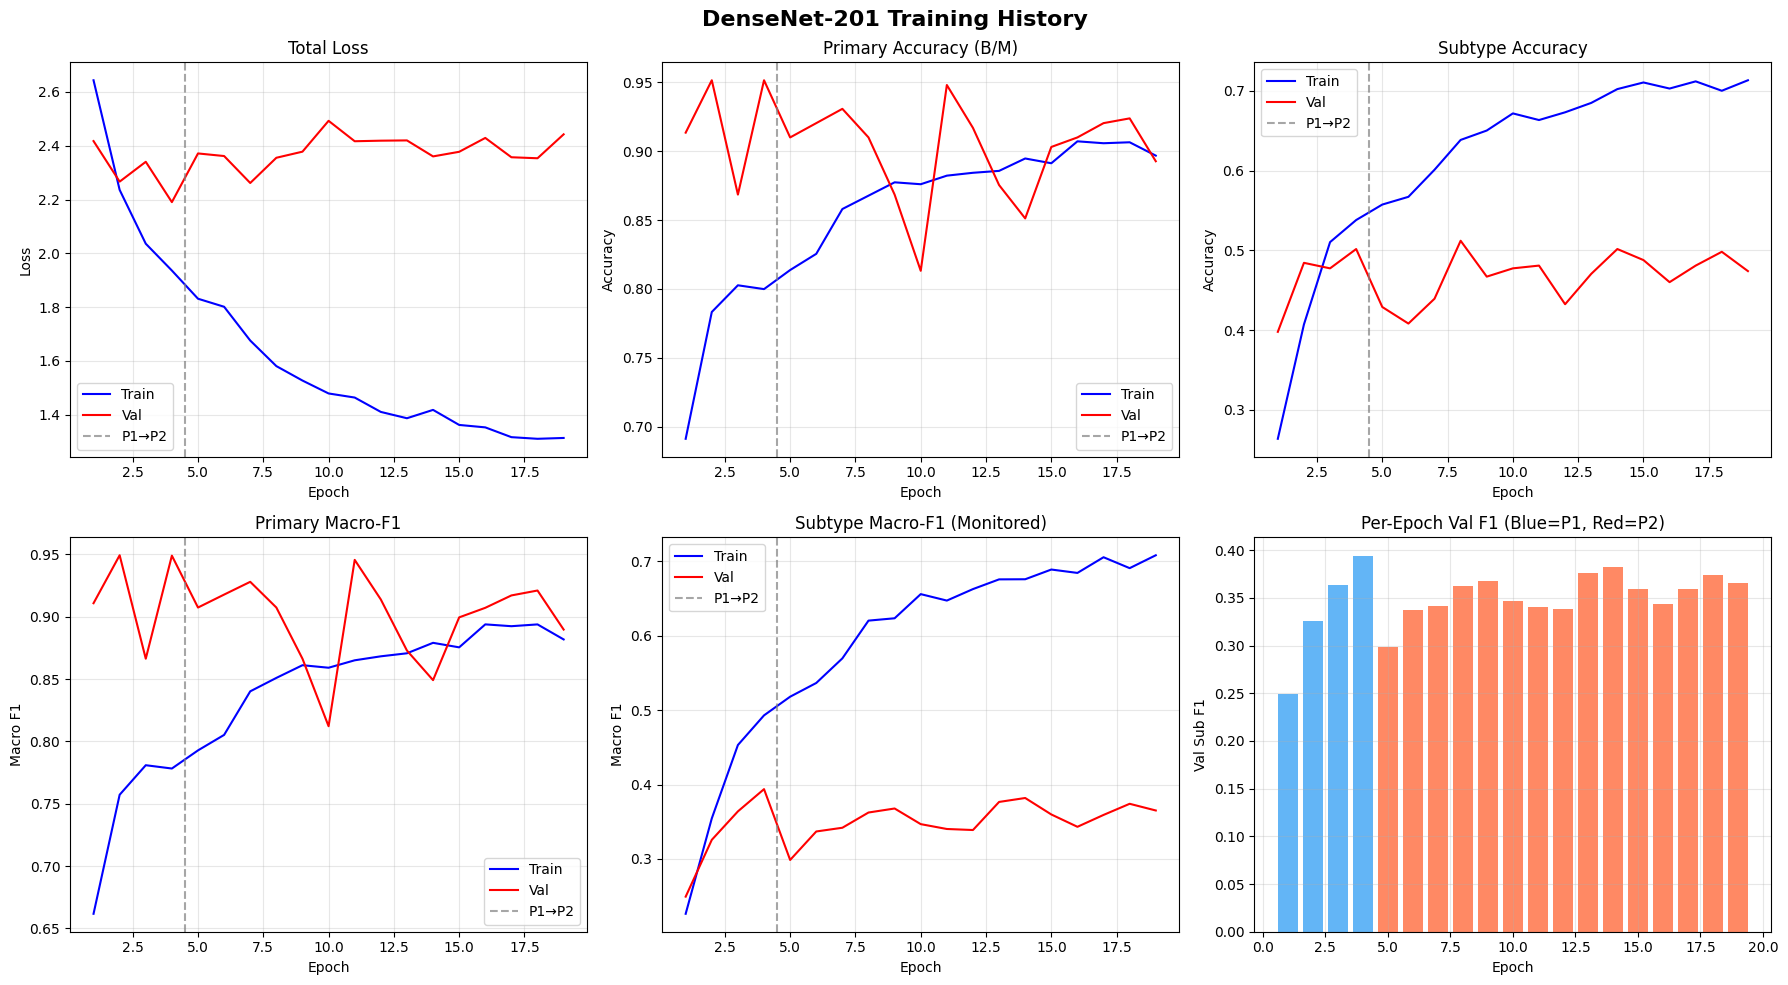

✅ Training plots saved.


In [ ]:
# ============================================================
# Training History Visualization
# ============================================================
h = history
epochs_range = range(1, len(h['train_loss']) + 1)
phase1_end = sum(1 for p in h['phase'] if p == 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DenseNet-201 Training History', fontsize=16, fontweight='bold')

titles = ['Total Loss', 'Primary Accuracy (B/M)', 'Subtype Accuracy',
          'Primary Macro-F1', 'Subtype Macro-F1 (Monitored)', 'Val F1 by Phase']
train_keys = ['train_loss', 'train_primary_acc', 'train_subtype_acc',
              'train_primary_f1', 'train_subtype_f1', None]
val_keys   = ['val_loss', 'val_primary_acc', 'val_subtype_acc',
              'val_primary_f1', 'val_subtype_f1', None]
ylabels = ['Loss', 'Accuracy', 'Accuracy', 'Macro F1', 'Macro F1', 'Val Sub F1']

for i in range(5):
    ax = axes[i // 3][i % 3]
    ax.plot(epochs_range, h[train_keys[i]], 'b-', label='Train', lw=1.5)
    ax.plot(epochs_range, h[val_keys[i]],   'r-', label='Val',   lw=1.5)
    if phase1_end > 0:
        ax.axvline(x=phase1_end + 0.5, color='gray', ls='--', alpha=.7, label='P1\u2192P2')
    ax.set(xlabel='Epoch', ylabel=ylabels[i], title=titles[i])
    ax.legend(); ax.grid(True, alpha=.3)

# Bar chart: per-epoch val F1 coloured by phase
ax = axes[1][2]
colors = ['#2196F3' if p == 1 else '#FF5722' for p in h['phase']]
ax.bar(epochs_range, h['val_subtype_f1'], color=colors, alpha=0.7)
ax.set(xlabel='Epoch', ylabel='Val Sub F1', title='Per-Epoch Val F1 (Blue=P1, Red=P2)')
ax.grid(True, alpha=.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_history.png"), dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Training plots saved.")

## Final Evaluation on Held-Out Test Set

> **This is the only time the test set is used.** Model selection is complete.

| Task | Metrics |
|------|---------|
| A (primary) | Accuracy, Precision, Recall, F1, confusion matrix |
| B (subtype) | Accuracy, Macro P/R/F1, per-class P/R/F1, confusion matrix |

In [ ]:
# ============================================================
# Final Test-Set Evaluation
# ============================================================
print("=" * 60)
print("FINAL TEST-SET EVALUATION")
print("=" * 60)

# Load best checkpoint
assert os.path.exists(BEST_CHECKPOINT_PATH), \
    f"\u274c Best checkpoint not found at {BEST_CHECKPOINT_PATH}!"
print(f"\nLoading: {BEST_CHECKPOINT_PATH}")

model_eval = DenseNet201MultiTask(CONFIG).to(device)
ckpt = load_checkpoint(model_eval, BEST_CHECKPOINT_PATH)
model_eval.eval()

# Collect all predictions
ap_p, at_p, ap_s, at_s = [], [], [], []
with torch.no_grad():
    for imgs, yp, ys in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=CONFIG['optim']['mixed_precision']):
            lp, ls, _ = model_eval(imgs)
        ap_p.append(lp.argmax(1).cpu()); at_p.append(yp)
        ap_s.append(ls.argmax(1).cpu()); at_s.append(ys)

ap_p = torch.cat(ap_p).numpy(); at_p = torch.cat(at_p).numpy()
ap_s = torch.cat(ap_s).numpy(); at_s = torch.cat(at_s).numpy()

# ---- Task A ----
print(f"\n{'=' * 60}")
print("TASK A: PRIMARY CLASSIFICATION (Benign vs Malignant)")
print(f"{'=' * 60}")
pri_names = [PRIMARY_IDX_TO_LABEL[i] for i in range(CONFIG['model']['primary_num_classes'])]
pri_acc  = accuracy_score(at_p, ap_p)
pri_prec = precision_score(at_p, ap_p, average='macro', zero_division=0)
pri_rec  = recall_score(at_p, ap_p, average='macro', zero_division=0)
pri_f1   = f1_score(at_p, ap_p, average='macro', zero_division=0)
print(f"\n  Accuracy:  {pri_acc:.4f}")
print(f"  Precision: {pri_prec:.4f}")
print(f"  Recall:    {pri_rec:.4f}")
print(f"  F1:        {pri_f1:.4f}")
print("\n" + classification_report(at_p, ap_p, target_names=pri_names, zero_division=0))
pri_cm = confusion_matrix(at_p, ap_p)

# ---- Task B ----
print(f"{'=' * 60}")
print("TASK B: SUBTYPE CLASSIFICATION (8 classes)")
print(f"{'=' * 60}")
sub_names = [SUBTYPE_IDX_TO_LABEL[i] for i in range(CONFIG['model']['subtype_num_classes'])]
sub_acc  = accuracy_score(at_s, ap_s)
sub_prec = precision_score(at_s, ap_s, average='macro', zero_division=0)
sub_rec  = recall_score(at_s, ap_s, average='macro', zero_division=0)
sub_f1   = f1_score(at_s, ap_s, average='macro', zero_division=0)
print(f"\n  Accuracy:        {sub_acc:.4f}")
print(f"  Macro Precision: {sub_prec:.4f}")
print(f"  Macro Recall:    {sub_rec:.4f}")
print(f"  Macro F1:        {sub_f1:.4f}")
print("\n" + classification_report(at_s, ap_s, target_names=sub_names, zero_division=0))
sub_cm = confusion_matrix(at_s, ap_s)

# ---- Save metrics ----
pc_prec = precision_score(at_s, ap_s, average=None, zero_division=0)
pc_rec  = recall_score(at_s, ap_s, average=None, zero_division=0)
pc_f1   = f1_score(at_s, ap_s, average=None, zero_division=0)

test_metrics = {
    'task_a_primary': {
        'accuracy': float(pri_acc), 'precision_macro': float(pri_prec),
        'recall_macro': float(pri_rec), 'f1_macro': float(pri_f1),
    },
    'task_b_subtype': {
        'accuracy': float(sub_acc), 'precision_macro': float(sub_prec),
        'recall_macro': float(sub_rec), 'f1_macro': float(sub_f1),
        'per_class': {
            sub_names[i]: {
                'precision': float(pc_prec[i]), 'recall': float(pc_rec[i]),
                'f1': float(pc_f1[i]), 'support': int((at_s == i).sum()),
            } for i in range(len(sub_names))
        }
    },
    'config': {
        'backbone': CONFIG['model']['backbone'],
        'magnification': CONFIG['data']['magnification'],
        'seed': CONFIG['seed'],
        'best_val_f1': float(ckpt.get('best_val_f1', 0)),
    }
}

with open(os.path.join(SAVE_DIR, "test_metrics.json"), 'w') as f:
    json.dump(test_metrics, f, indent=2)

rows = [{'class': sub_names[i], 'precision': float(pc_prec[i]),
         'recall': float(pc_rec[i]), 'f1': float(pc_f1[i]),
         'support': int((at_s == i).sum())} for i in range(len(sub_names))]
pd.DataFrame(rows).to_csv(os.path.join(SAVE_DIR, "test_metrics_per_class.csv"), index=False)

print(f"\n\u2705 Metrics saved to {SAVE_DIR}/test_metrics.json")
print(f"\u2705 Per-class saved to {SAVE_DIR}/test_metrics_per_class.csv")

FINAL TEST-SET EVALUATION

Loading: /content/drive/MyDrive/output_CNN/best_densenet201.pth
   Loaded ImageNet-pretrained DenseNet-201
   Loaded checkpoint from epoch 3
   Best val F1: 0.3937620966817024


Testing:   0%|          | 0/18 [00:00<?, ?it/s]


TASK A: PRIMARY CLASSIFICATION (Benign vs Malignant)

  Accuracy:  0.7679
  Precision: 0.7274
  Recall:    0.6845
  F1:        0.6975

              precision    recall  f1-score   support

      benign       0.66      0.48      0.55        84
   malignant       0.80      0.89      0.84       196

    accuracy                           0.77       280
   macro avg       0.73      0.68      0.70       280
weighted avg       0.76      0.77      0.76       280

TASK B: SUBTYPE CLASSIFICATION (8 classes)

  Accuracy:        0.5107
  Macro Precision: 0.2804
  Macro Recall:    0.2587
  Macro F1:        0.2556

                     precision    recall  f1-score   support

           adenosis       0.50      0.19      0.27        32
       fibroadenoma       0.50      0.40      0.44        35
    phyllodes_tumor       0.00      0.00      0.00         0
    tubular_adenoma       0.23      0.41      0.29        17
   ductal_carcinoma       0.82      0.80      0.81       139
  lobular_carcinoma  

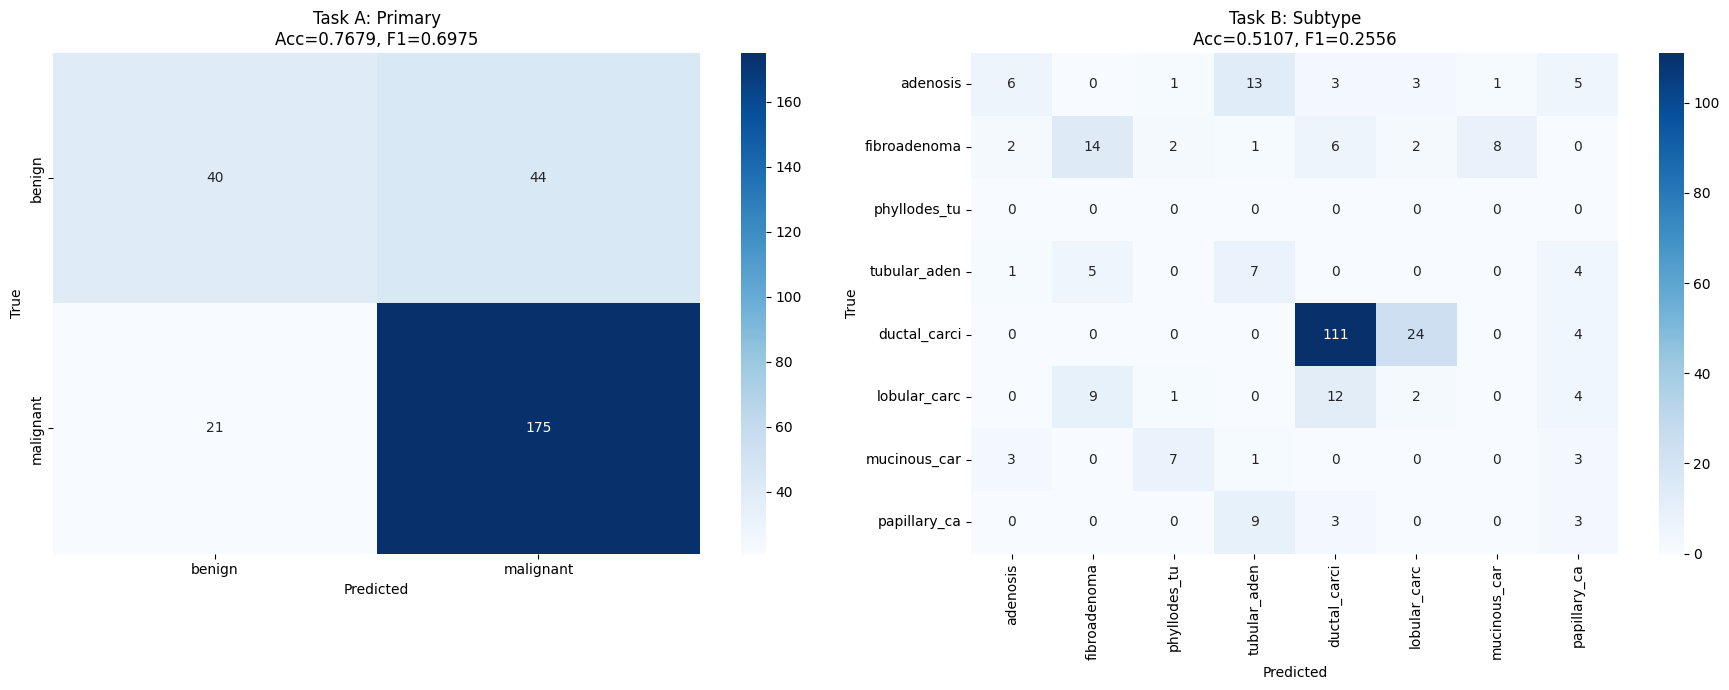

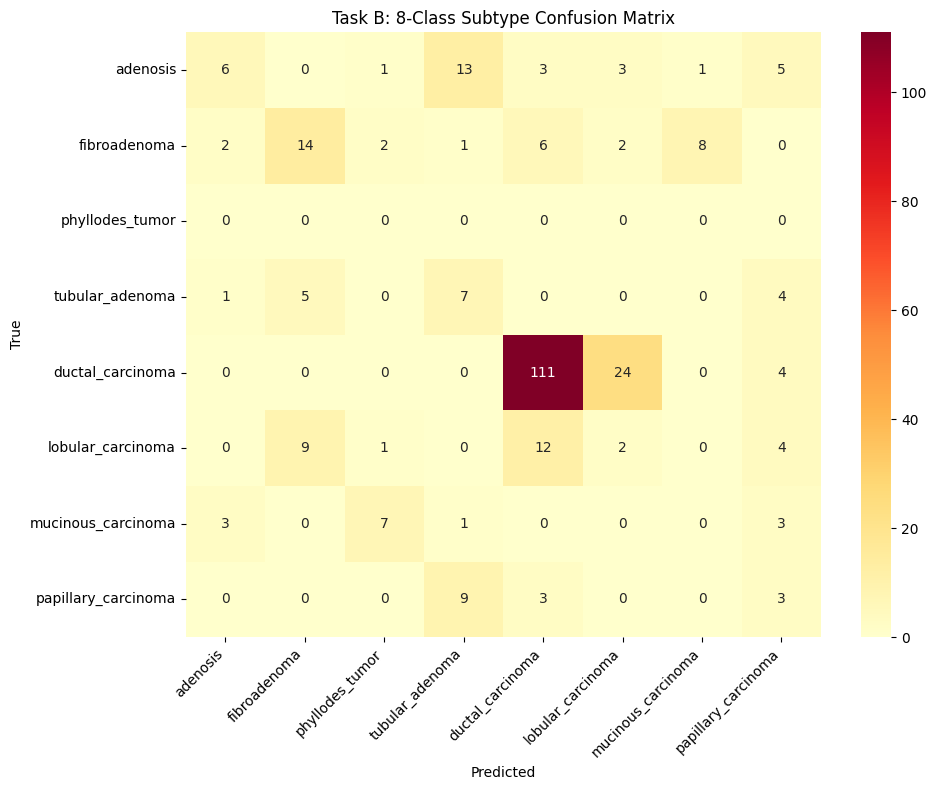

✅ Confusion matrices saved.


In [ ]:
# ============================================================
# Confusion Matrix Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
sns.heatmap(pri_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=pri_names, yticklabels=pri_names)
ax.set(xlabel='Predicted', ylabel='True',
       title=f'Task A: Primary\nAcc={pri_acc:.4f}, F1={pri_f1:.4f}')

ax = axes[1]
short = [s[:12] for s in sub_names]
sns.heatmap(sub_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=short, yticklabels=short)
ax.set(xlabel='Predicted', ylabel='True',
       title=f'Task B: Subtype\nAcc={sub_acc:.4f}, F1={sub_f1:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()

# Detailed subtype CM
fig2, ax2 = plt.subplots(figsize=(10, 8))
sns.heatmap(sub_cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax2,
            xticklabels=sub_names, yticklabels=sub_names)
ax2.set(xlabel='Predicted', ylabel='True',
        title='Task B: 8-Class Subtype Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix_subtype_detailed.png"),
            dpi=200, bbox_inches='tight')
plt.show()
print("\u2705 Confusion matrices saved.")

In [ ]:
# ============================================================
# Embedding Extraction Verification (for Experiment 3)
# ============================================================
print("=" * 60)
print("EMBEDDING EXTRACTION")
print("=" * 60)

model_emb = DenseNet201MultiTask(CONFIG).to(device)
load_checkpoint(model_emb, BEST_CHECKPOINT_PATH)
model_emb.eval()

print("\n--- Embedding Extraction Method ---")
print("  Layer:     DenseNet-201 features -> ReLU -> AdaptiveAvgPool2d(1,1) -> Flatten")
print(f"  Dimension: {CONFIG['model']['embedding_dim']}")
print("  API call:  model.extract_features(x)  ->  Tensor[B, 1920]")

sample_imgs, _, _ = next(iter(test_loader))
sample_imgs = sample_imgs.to(device)

with torch.no_grad():
    embs = model_emb.extract_features(sample_imgs)

assert embs.shape[1] == CONFIG['model']['embedding_dim'], \
    f"\u274c Expected dim {CONFIG['model']['embedding_dim']}, got {embs.shape[1]}"

print(f"\n\u2705 Shape: {embs.shape}")
print(f"   Min:  {embs.min().item():.4f}")
print(f"   Max:  {embs.max().item():.4f}")
print(f"   Mean: {embs.mean().item():.4f}")
print(f"   Std:  {embs.std().item():.4f}")

torch.save({
    'embeddings': embs.cpu(),
    'shape': list(embs.shape),
    'embedding_dim': CONFIG['model']['embedding_dim'],
    'extraction_method': 'model.extract_features(x)',
    'layer': 'features -> ReLU -> AdaptiveAvgPool2d(1,1) -> Flatten',
}, os.path.join(SAVE_DIR, "sample_embeddings.pt"))

del model_emb, embs, sample_imgs; torch.cuda.empty_cache()

print(f"\n\u2705 Sample embeddings saved to {SAVE_DIR}/sample_embeddings.pt")
print("\n" + "\u2500" * 60)
print("EXPERIMENT 3 REUSE INSTRUCTIONS")
print("\u2500" * 60)
print("  1. Instantiate: model = DenseNet201MultiTask(CONFIG)")
print(f"  2. Load:        ckpt = torch.load('{BEST_CHECKPOINT_PATH}', weights_only=False)")
print("  3. Apply:       model.load_state_dict(ckpt['model_state_dict'])")
print("  4. Extract:     emb = model.extract_features(images)  # [B, 1920]")

EMBEDDING EXTRACTION
   Loaded ImageNet-pretrained DenseNet-201
   Loaded checkpoint from epoch 3
   Best val F1: 0.3937620966817024

--- Embedding Extraction Method ---
  Layer:     DenseNet-201 features -> ReLU -> AdaptiveAvgPool2d(1,1) -> Flatten
  Dimension: 1920
  API call:  model.extract_features(x)  ->  Tensor[B, 1920]

✅ Shape: torch.Size([16, 1920])
   Min:  0.0000
   Max:  9.2375
   Mean: 0.2585
   Std:  0.5590

✅ Sample embeddings saved to /content/drive/MyDrive/output_CNN/sample_embeddings.pt

────────────────────────────────────────────────────────────
EXPERIMENT 3 REUSE INSTRUCTIONS
────────────────────────────────────────────────────────────
  1. Instantiate: model = DenseNet201MultiTask(CONFIG)
  2. Load:        ckpt = torch.load('/content/drive/MyDrive/output_CNN/best_densenet201.pth', weights_only=False)
  3. Apply:       model.load_state_dict(ckpt['model_state_dict'])
  4. Extract:     emb = model.extract_features(images)  # [B, 1920]


## Deliverables Checklist

| # | Artifact | Status |
|---|----------|--------|
| 1 | Data audit output (class counts, patient counts, split verification) | ✅ Printed above |
| 2 | `split.csv` — patient-level split (shared for Exp 1–3) | ✅ Saved to Drive |
| 3 | Trained DenseNet-201 notebook (`.ipynb`) | ✅ This notebook |
| 4 | Best checkpoint (`best_densenet201.pth`) | ✅ Saved to Drive |
| 5 | Test-set metrics (JSON + CSV) | ✅ Saved to Drive |
| 6 | Confusion matrices (images) | ✅ Saved to Drive |
| 7 | Embedding extraction method documented | ✅ Cell above |
| 8 | Recorded hyperparameters (CONFIG) | ✅ CONFIG cell + checkpoint |
| 9 | Training history (CSV + plots) | ✅ Saved to Drive |
| 10 | CV results | ✅ Saved to Drive |

---
**Experiment 1 complete.** Proceed to Experiment 2 (ViT-B/16) using the same `split.csv`.